# Translation Flows into English (2008–2017)

An interactive analysis of fiction and poetry translated into English, based on the *Three Percent* Translation Database. This notebook explores:

1. **Global translation flow map** — where translations originate
2. **Trends over time** — total output, by language, by country, by genre
3. **Top publishers** in translated literature
4. **Most-translated authors**
5. **Gender breakdown** of authors and translators

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Style ──
sns.set_theme(style='whitegrid', font_scale=1.1)
palette = sns.color_palette('husl', 15)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# ── Load Data ──
df = pd.read_csv('translation_database.csv')

# Filter to 2008-2017 (2018 has only partial data)
df = df[df['Pub Year'].between(2008, 2017)].copy()

# Create full author name
df['Author'] = (df['Author First Name'].fillna('') + ' ' + df['Author Last Name'].fillna('')).str.strip()
df['Translator'] = (df['Trans First Name'].fillna('') + ' ' + df['Trans Last Name'].fillna('')).str.strip()

# Clean: remove placeholder author names
df = df[~df['Author'].str.lower().isin(['various', 'various various', 'anonymous', ''])].copy()

print(f'Total titles: {len(df):,}')
print(f'Year range: {df["Pub Year"].min()} – {df["Pub Year"].max()}')
print(f'Languages: {df["Language"].nunique()}')
print(f'Countries: {df["Country"].nunique()}')
print(f'Publishers: {df["Publisher"].nunique()}')
print(f'Unique Authors: {df["Author"].nunique()}')

Total titles: 4,808
Year range: 2008 – 2017
Languages: 78
Countries: 134
Publishers: 517
Unique Authors: 3250


---
## 1. Global Translation Flow Map

Each arrow represents a flow of translated titles from the source country to the US (the destination market). Arrow thickness is proportional to the number of titles.

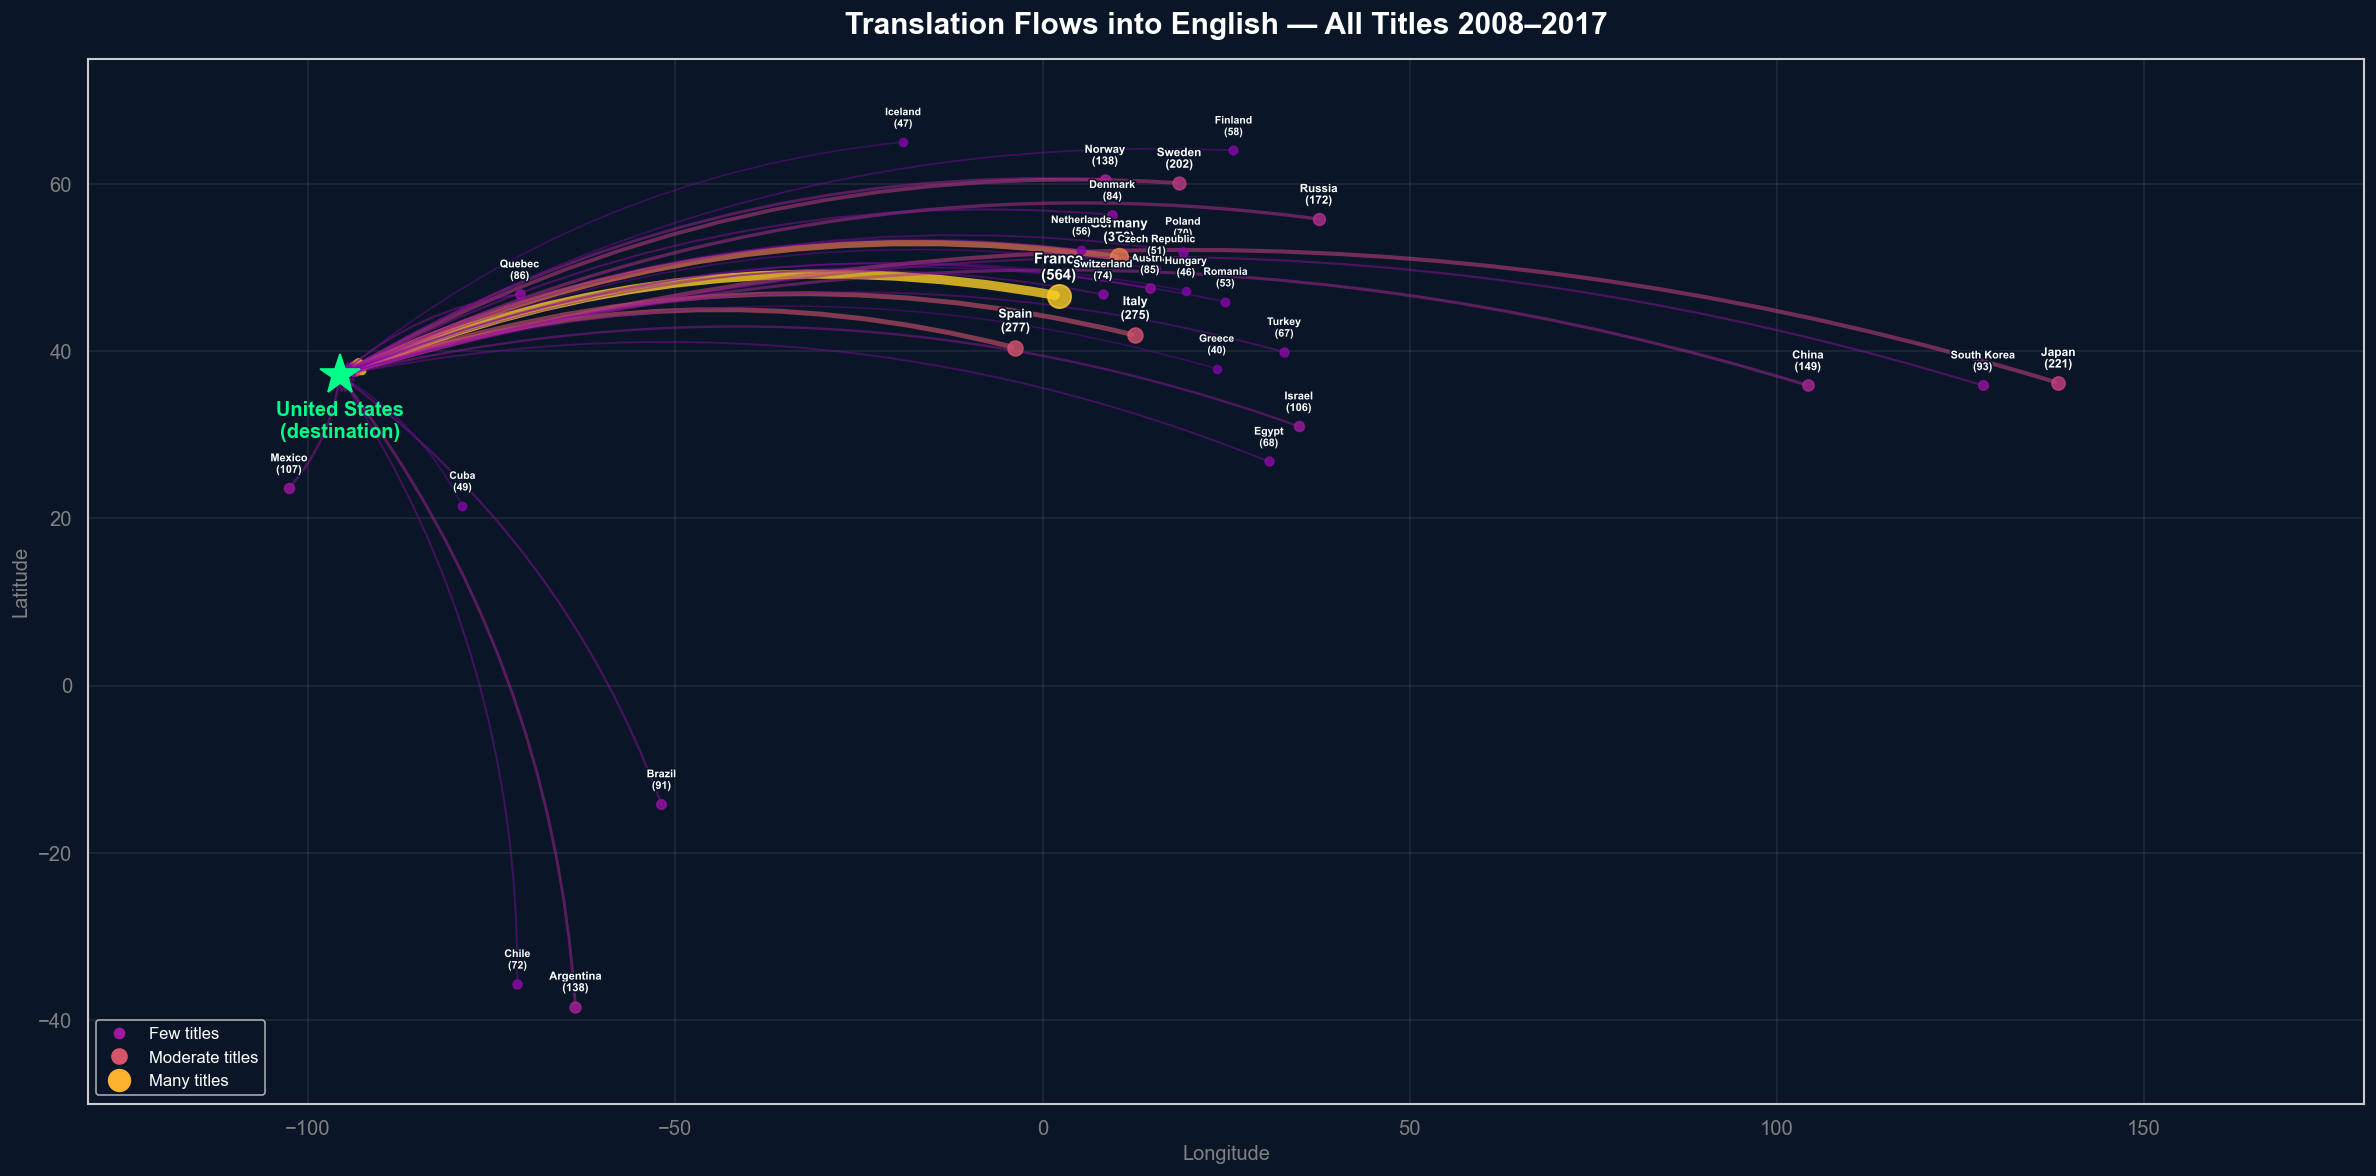


Map shows top 30 source countries (3,915 titles, 81.4% of all translations)


In [14]:
# ── Country coordinates (approximate centroids) ──
COORDS = {
    'France': (2.2, 46.6), 'Germany': (10.4, 51.2), 'Spain': (-3.7, 40.4),
    'Italy': (12.6, 41.9), 'Japan': (138.3, 36.2), 'Sweden': (18.6, 60.1),
    'Russia': (37.6, 55.8), 'China': (104.2, 35.9), 'Argentina': (-63.6, -38.4),
    'Norway': (8.5, 60.5), 'Mexico': (-102.6, 23.6), 'Israel': (34.9, 31.0),
    'Brazil': (-51.9, -14.2), 'South Korea': (128.0, 35.9),
    'Quebec': (-71.2, 46.8), 'Denmark': (9.5, 56.3), 'Austria': (14.6, 47.5),
    'Poland': (19.1, 51.9), 'United Kingdom': (-1.2, 52.3),
    'Netherlands': (5.3, 52.1), 'Turkey': (32.9, 39.9), 'Chile': (-71.5, -35.7),
    'Colombia': (-74.3, 4.6), 'Czech Republic': (15.5, 49.8),
    'Hungary': (19.5, 47.2), 'Finland': (26.0, 64.0), 'Portugal': (-8.2, 39.4),
    'Iceland': (-19.0, 65.0), 'Switzerland': (8.2, 46.8), 'Cuba': (-79.0, 21.5),
    'Iran': (53.7, 32.4), 'Greece': (23.7, 37.9), 'Peru': (-75.0, -9.2),
    'Egypt': (30.8, 26.8), 'Romania': (24.9, 45.9), 'Nigeria': (8.7, 9.1),
    'Iraq': (44.4, 33.2), 'Serbia': (21.0, 44.0), 'Croatia': (15.2, 45.1),
    'India': (78.9, 20.6), 'Lebanon': (35.5, 33.9), 'Taiwan': (121.0, 23.7),
    'Ukraine': (31.2, 48.4), 'Vietnam': (108.3, 14.1), 'Belgium': (4.5, 50.5),
    'Georgia': (43.4, 42.3), 'Pakistan': (69.3, 30.4), 'Libya': (17.2, 26.3),
    'Syria': (39.0, 35.0), 'Catalonia': (1.5, 41.6), 'Algeria': (1.7, 28.0),
    'Mozambique': (35.5, -18.7), 'Angola': (17.9, -11.2),
    'Bosnia-Herzegovina': (17.7, 43.9), 'Latvia': (24.6, 56.9),
    'Bulgaria': (25.5, 42.7), 'Lithuania': (23.9, 55.2),
    'Macedonia': (21.7, 41.5), 'Morocco': (-7.1, 31.8), 'Palestine': (35.2, 31.9),
    'Kenya': (37.9, 0.0), 'Somalia': (46.2, 5.2), 'Indonesia': (113.9, -0.8),
    'Congo': (21.8, -4.0), 'Cameroon': (12.4, 7.4), 'Senegal': (-14.5, 14.5),
    'Thailand': (100.5, 15.9), 'Uruguay': (-55.8, -32.5),
    'Costa Rica': (-84.1, 9.7), 'Philippines': (122.0, 12.9),
    'Ethiopia': (40.5, 9.1), 'South Africa': (22.9, -30.6),
    'Guatemala': (-90.2, 15.8), 'El Salvador': (-88.9, 13.8),
    'Dominican Republic': (-70.2, 18.7), 'Paraguay': (-58.4, -23.4),
    'Ecuador': (-78.2, -1.8), 'Honduras': (-86.2, 15.2),
    'Nicaragua': (-85.2, 12.9), 'Venezuela': (-66.6, 6.4),
    'Puerto Rico': (-66.6, 18.2), 'Panama': (-80.8, 8.5),
    'Equatorial Guinea': (10.3, 1.7), 'Rwanda': (29.9, -1.9),
    'Slovenia': (15.0, 46.2), 'Albania': (20.2, 41.2),
    'Bolivia': (-65.0, -16.3), 'Slovakia': (19.7, 48.7),
    'Estonia': (25.0, 58.6), 'Myanmar': (96.0, 19.8),
    'Ivory Coast': (-5.5, 7.5), 'Guinea': (-10.0, 10.0),
    'Martinique': (-61.0, 14.6), 'Guadeloupe': (-61.6, 16.3),
    'Tunisia': (9.5, 34.0), 'Zimbabwe': (29.2, -19.0),
    'Afghanistan': (67.7, 33.9), 'Bangladesh': (90.4, 23.7),
    'Mali': (-2.0, 17.6), 'Mongolia': (103.8, 46.9),
    'New Zealand': (174.9, -40.9), 'Sudan': (30.2, 12.9),
    'Uzbekistan': (64.6, 41.4), 'Belarus': (27.9, 53.7),
    'Haiti': (-72.3, 18.9), 'Kurdistan': (44.0, 36.2),
    'Sri Lanka': (80.8, 7.9), 'Tanzania': (34.9, -6.4),
    'Yemen': (48.5, 15.6), 'Cambodia': (105.0, 12.6),
    'Galicia': (-7.9, 42.7), 'Jordan': (36.2, 30.6),
    'Nepal': (84.1, 28.4), 'Luxembourg': (6.1, 49.8)
}

US = (-95.7, 37.1)  # destination

country_counts = df['Country'].value_counts()
top_countries = country_counts.head(30)

fig, ax = plt.subplots(figsize=(20, 10))
ax.set_facecolor('#0a1628')
fig.patch.set_facecolor('#0a1628')

# Draw flows
max_count = top_countries.max()
cmap = plt.cm.plasma

for country, count in top_countries.items():
    if country in COORDS:
        cx, cy = COORDS[country]
        intensity = count / max_count
        lw = 0.5 + intensity * 5
        color = cmap(0.2 + intensity * 0.7)
        
        ax.annotate('',
            xy=US, xytext=(cx, cy),
            arrowprops=dict(
                arrowstyle='->', color=color,
                lw=lw, alpha=0.4 + intensity * 0.4,
                connectionstyle='arc3,rad=0.15'
            )
        )
        
        # Source label
        ax.plot(cx, cy, 'o', color=color, markersize=4 + intensity * 10,
                alpha=0.8, zorder=5)
        ax.annotate(f'{country}\n({count})',
            (cx, cy), fontsize=6 + intensity * 3,
            color='white', ha='center', va='bottom',
            fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='#0a1628')],
            xytext=(0, 8), textcoords='offset points', zorder=6)

# US marker
ax.plot(*US, '*', color='#00ff88', markersize=25, zorder=10)
ax.annotate('United States\n(destination)', US, fontsize=12, color='#00ff88',
    ha='center', va='top', fontweight='bold',
    xytext=(0, -15), textcoords='offset points', zorder=10)

ax.set_xlim(-130, 180)
ax.set_ylim(-50, 75)
ax.set_title('Translation Flows into English — All Titles 2008–2017',
    color='white', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', color='gray')
ax.set_ylabel('Latitude', color='gray')
ax.tick_params(colors='gray')
ax.grid(True, alpha=0.1)

# Legend
for val, label in [(0.2, 'Few'), (0.5, 'Moderate'), (0.9, 'Many')]:
    ax.plot([], [], 'o', color=cmap(0.2 + val * 0.7),
            markersize=4 + val * 10, label=f'{label} titles')
ax.legend(loc='lower left', fontsize=10, facecolor='#0a1628',
    labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()
print(f'\nMap shows top 30 source countries ({top_countries.sum():,} titles, '
      f'{top_countries.sum()/len(df)*100:.1f}% of all translations)')

---
## 2. Translation Trends Over Time

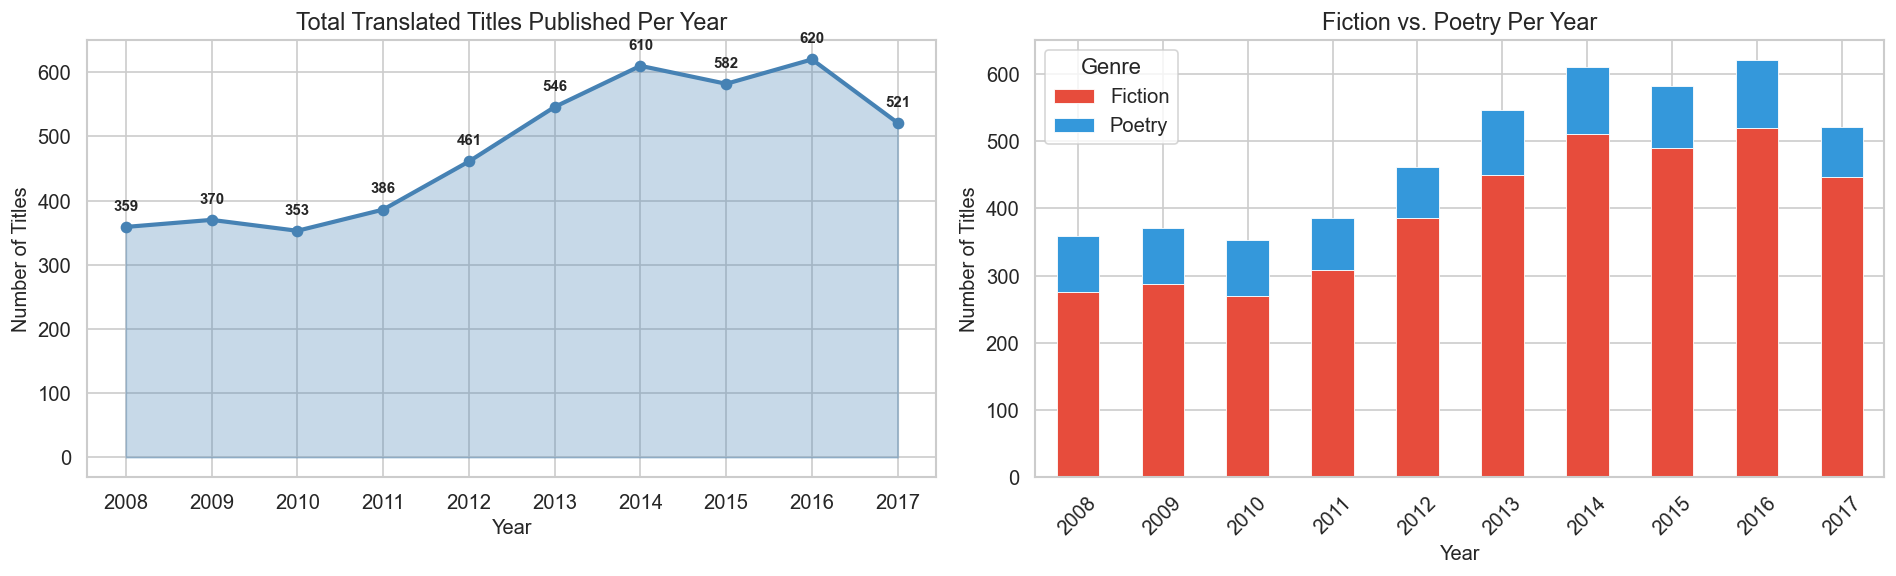

In [15]:
# ── 2a. Total translations per year (fiction vs. poetry) ──
yearly = df.groupby(['Pub Year', 'Genre']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total
total_year = df.groupby('Pub Year').size()
axes[0].fill_between(total_year.index, total_year.values, alpha=0.3, color='steelblue')
axes[0].plot(total_year.index, total_year.values, 'o-', color='steelblue', lw=2.5)
for x, y in zip(total_year.index, total_year.values):
    axes[0].annotate(str(y), (x, y), textcoords='offset points',
        xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Translated Titles Published Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Titles')
axes[0].set_xticks(range(2008, 2018))

# Fiction vs Poetry
yearly.plot(kind='bar', stacked=True, ax=axes[1],
    color=['#e74c3c', '#3498db'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Fiction vs. Poetry Per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Titles')
axes[1].legend(title='Genre')
axes[1].set_xticklabels(range(2008, 2018), rotation=45)

plt.tight_layout()
plt.show()

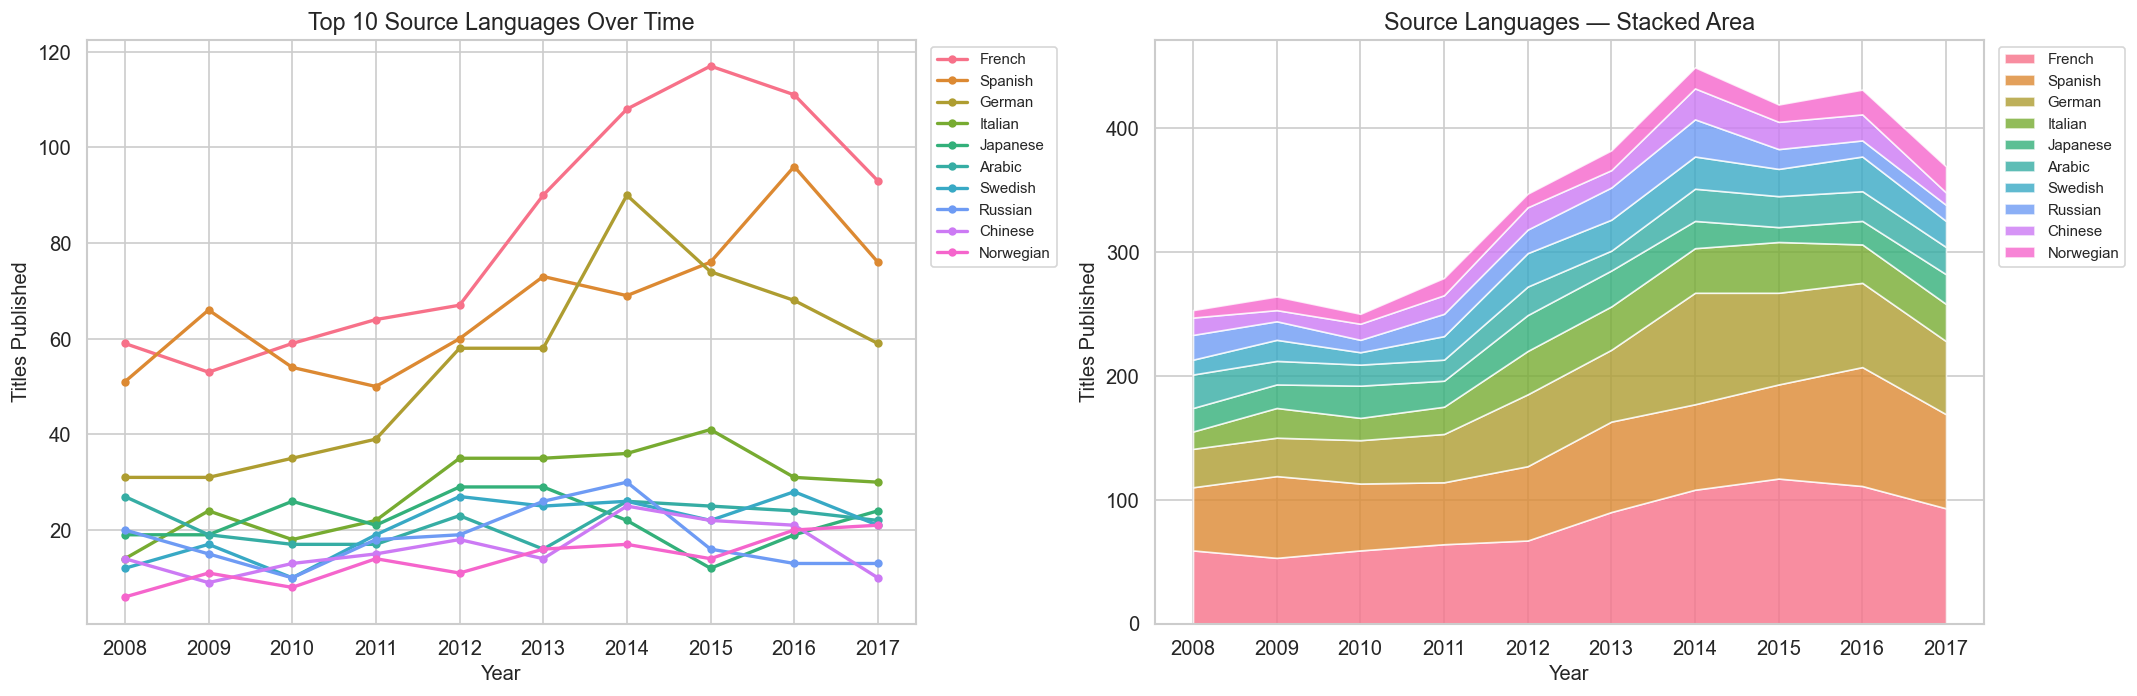

In [16]:
# ── 2b. Top 10 source languages over time ──
top_langs = df['Language'].value_counts().head(10).index.tolist()
lang_year = df[df['Language'].isin(top_langs)].groupby(['Pub Year', 'Language']).size().unstack(fill_value=0)
lang_year = lang_year[top_langs]  # reorder

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Line chart
colors = sns.color_palette('husl', 10)
for i, lang in enumerate(top_langs):
    axes[0].plot(lang_year.index, lang_year[lang], 'o-', label=lang,
        color=colors[i], lw=2, markersize=4)
axes[0].set_title('Top 10 Source Languages Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Titles Published')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].set_xticks(range(2008, 2018))

# Stacked area
axes[1].stackplot(lang_year.index, *[lang_year[l] for l in top_langs],
    labels=top_langs, colors=colors, alpha=0.8)
axes[1].set_title('Source Languages — Stacked Area')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Titles Published')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].set_xticks(range(2008, 2018))

plt.tight_layout()
plt.show()

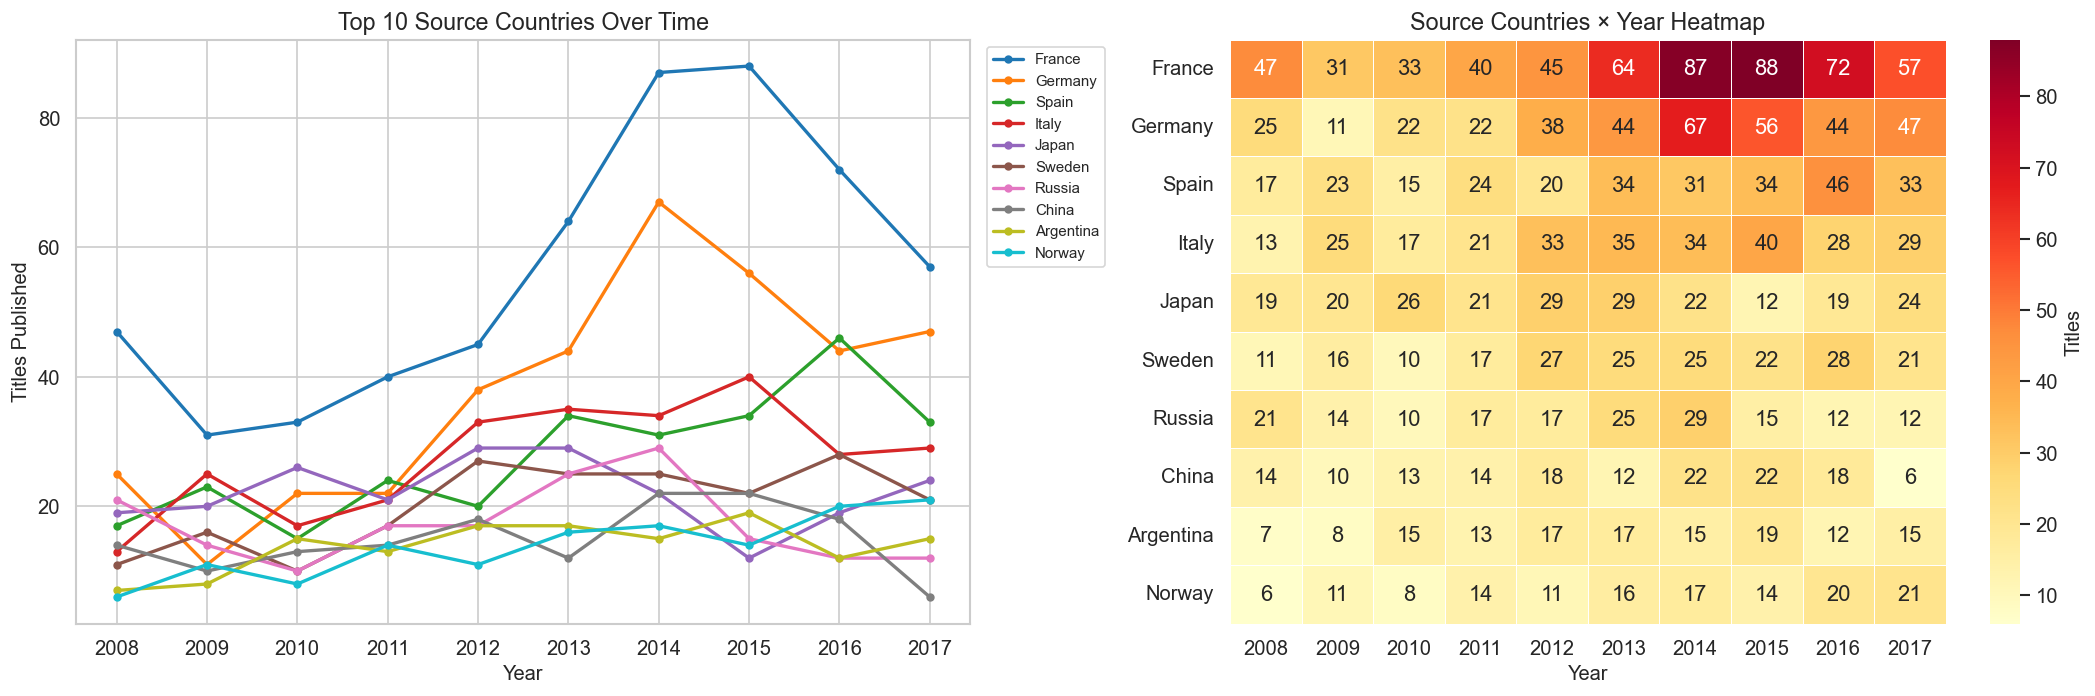

In [17]:
# ── 2c. Top 10 source countries over time ──
top_ctry = df['Country'].value_counts().head(10).index.tolist()
ctry_year = df[df['Country'].isin(top_ctry)].groupby(['Pub Year', 'Country']).size().unstack(fill_value=0)
ctry_year = ctry_year[top_ctry]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_c = sns.color_palette('tab10', 10)
for i, c in enumerate(top_ctry):
    axes[0].plot(ctry_year.index, ctry_year[c], 'o-', label=c,
        color=colors_c[i], lw=2, markersize=4)
axes[0].set_title('Top 10 Source Countries Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Titles Published')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].set_xticks(range(2008, 2018))

# Heatmap
sns.heatmap(ctry_year.T, annot=True, fmt='d', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Titles'})
axes[1].set_title('Source Countries × Year Heatmap')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

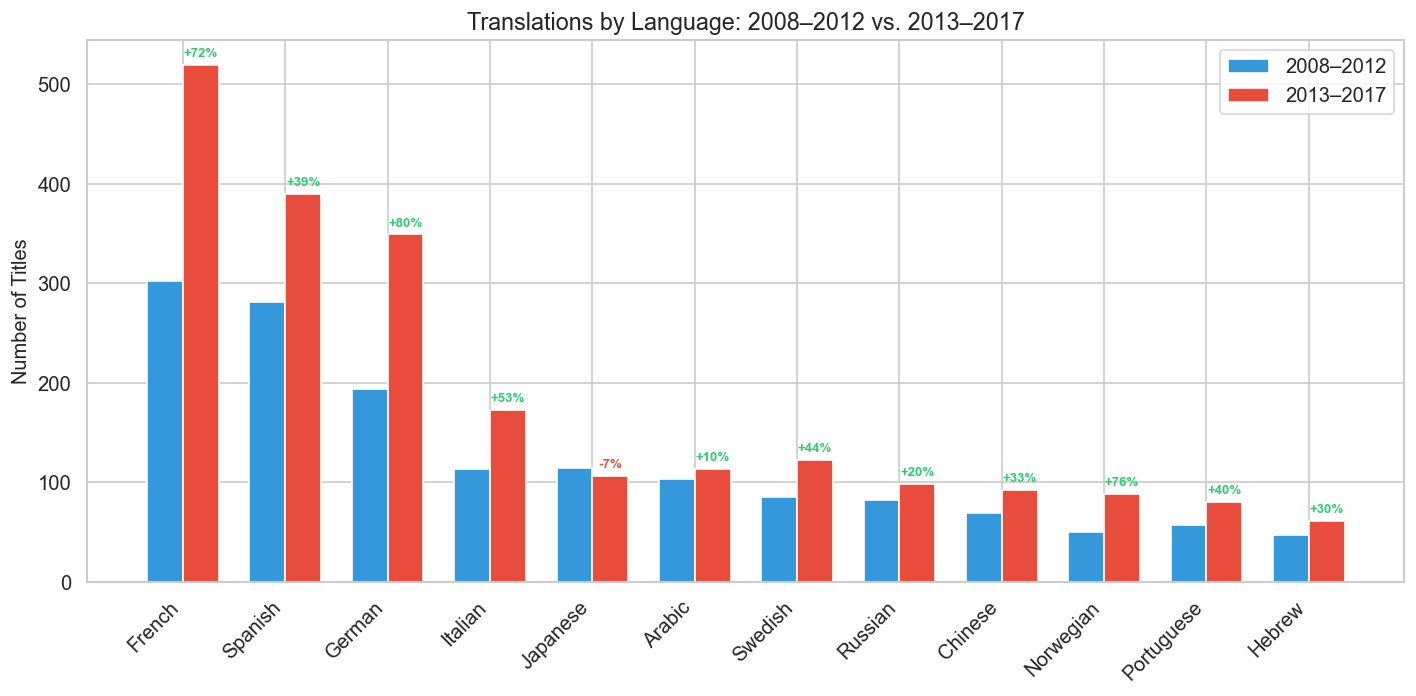

In [18]:
# ── 2d. Market share shift — % of translations by language (first half vs second half) ──
first_half = df[df['Pub Year'].between(2008, 2012)]
second_half = df[df['Pub Year'].between(2013, 2017)]

all_top = df['Language'].value_counts().head(12).index
fh = first_half['Language'].value_counts().reindex(all_top, fill_value=0)
sh = second_half['Language'].value_counts().reindex(all_top, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_top))
w = 0.35
bars1 = ax.bar(x - w/2, fh.values, w, label='2008–2012', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + w/2, sh.values, w, label='2013–2017', color='#e74c3c', edgecolor='white')

# Growth labels
for i in range(len(all_top)):
    if fh.values[i] > 0:
        pct = (sh.values[i] - fh.values[i]) / fh.values[i] * 100
        color = '#2ecc71' if pct > 0 else '#e74c3c'
        ax.annotate(f'{pct:+.0f}%', (x[i] + w/2, sh.values[i]),
            textcoords='offset points', xytext=(0, 5),
            ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_top, rotation=45, ha='right')
ax.set_title('Translations by Language: 2008–2012 vs. 2013–2017')
ax.set_ylabel('Number of Titles')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Top Publishers in Translation

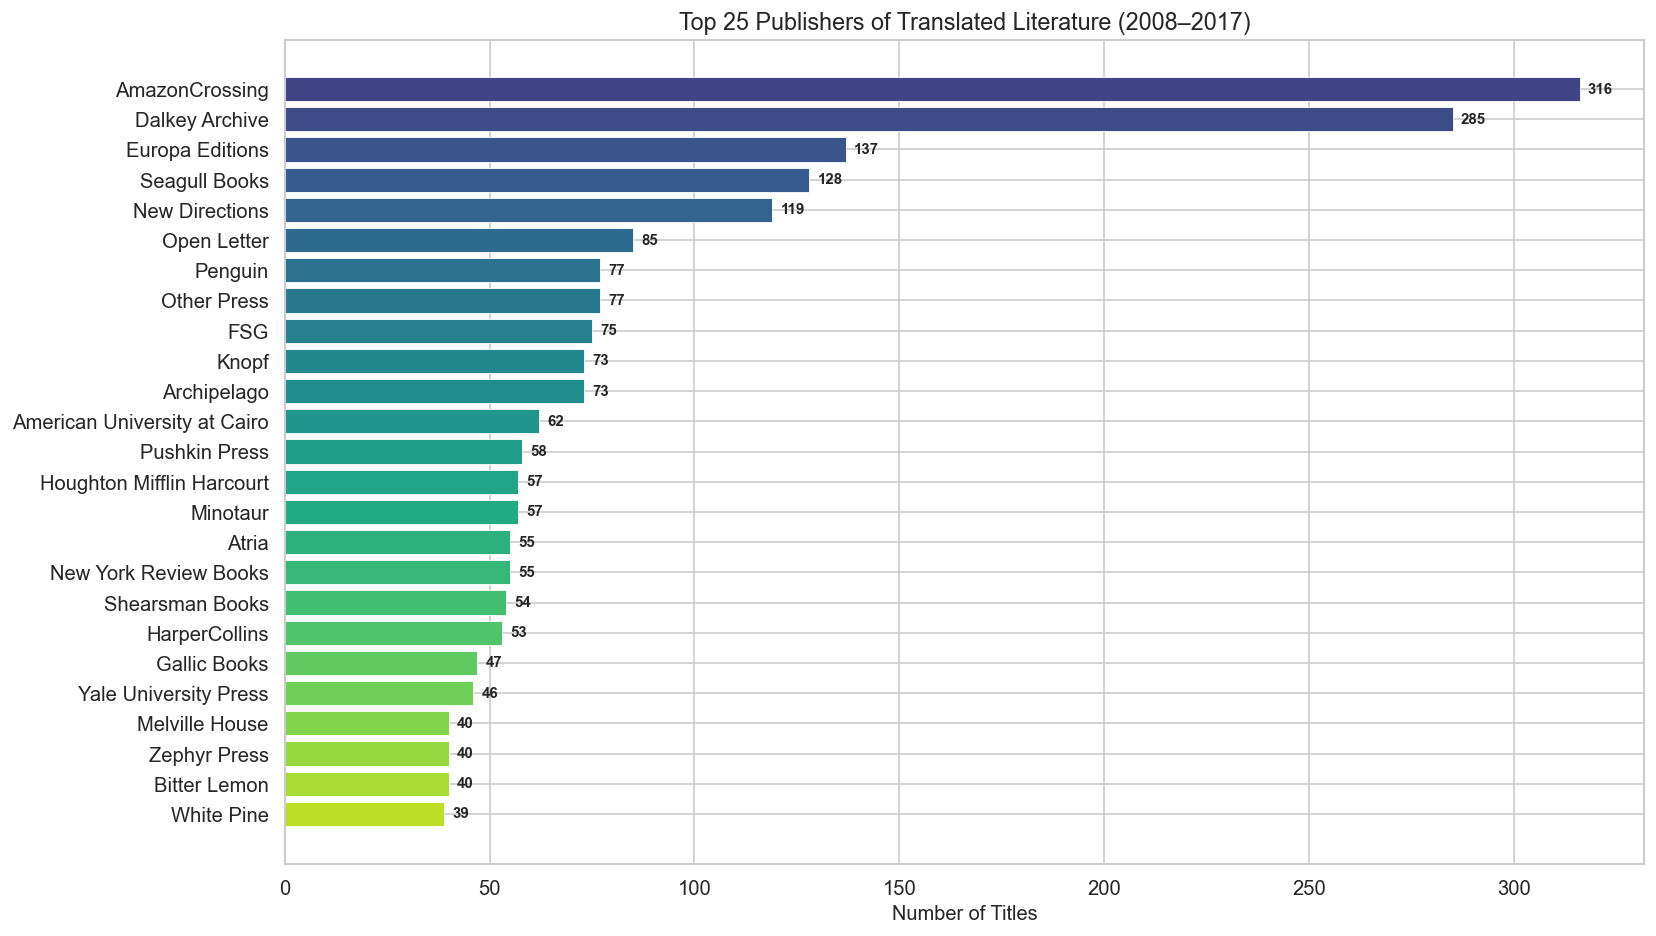

In [19]:
# ── 3a. Top 25 publishers overall ──
top_pubs = df['Publisher'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(14, 8))
colors_pub = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_pubs)))
bars = ax.barh(range(len(top_pubs)), top_pubs.values, color=colors_pub, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_pubs)))
ax.set_yticklabels(top_pubs.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Titles')
ax.set_title('Top 25 Publishers of Translated Literature (2008–2017)')

for i, v in enumerate(top_pubs.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

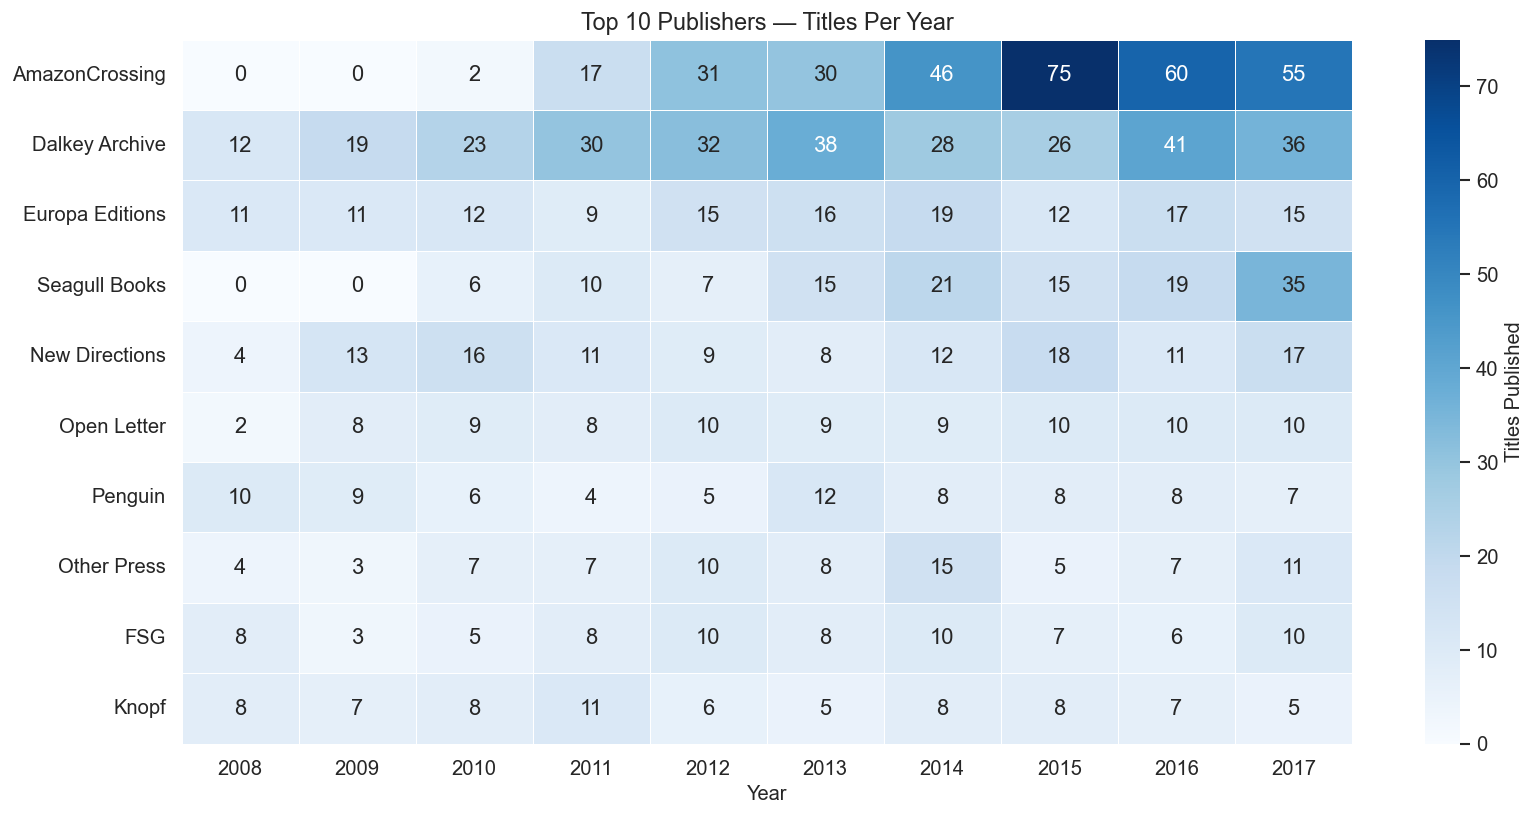

In [20]:
# ── 3b. Top 10 publishers over time ──
top10_pubs = df['Publisher'].value_counts().head(10).index.tolist()
pub_year = df[df['Publisher'].isin(top10_pubs)].groupby(['Pub Year', 'Publisher']).size().unstack(fill_value=0)
pub_year = pub_year[top10_pubs]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pub_year.T, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, cbar_kws={'label': 'Titles Published'}, ax=ax)
ax.set_title('Top 10 Publishers — Titles Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

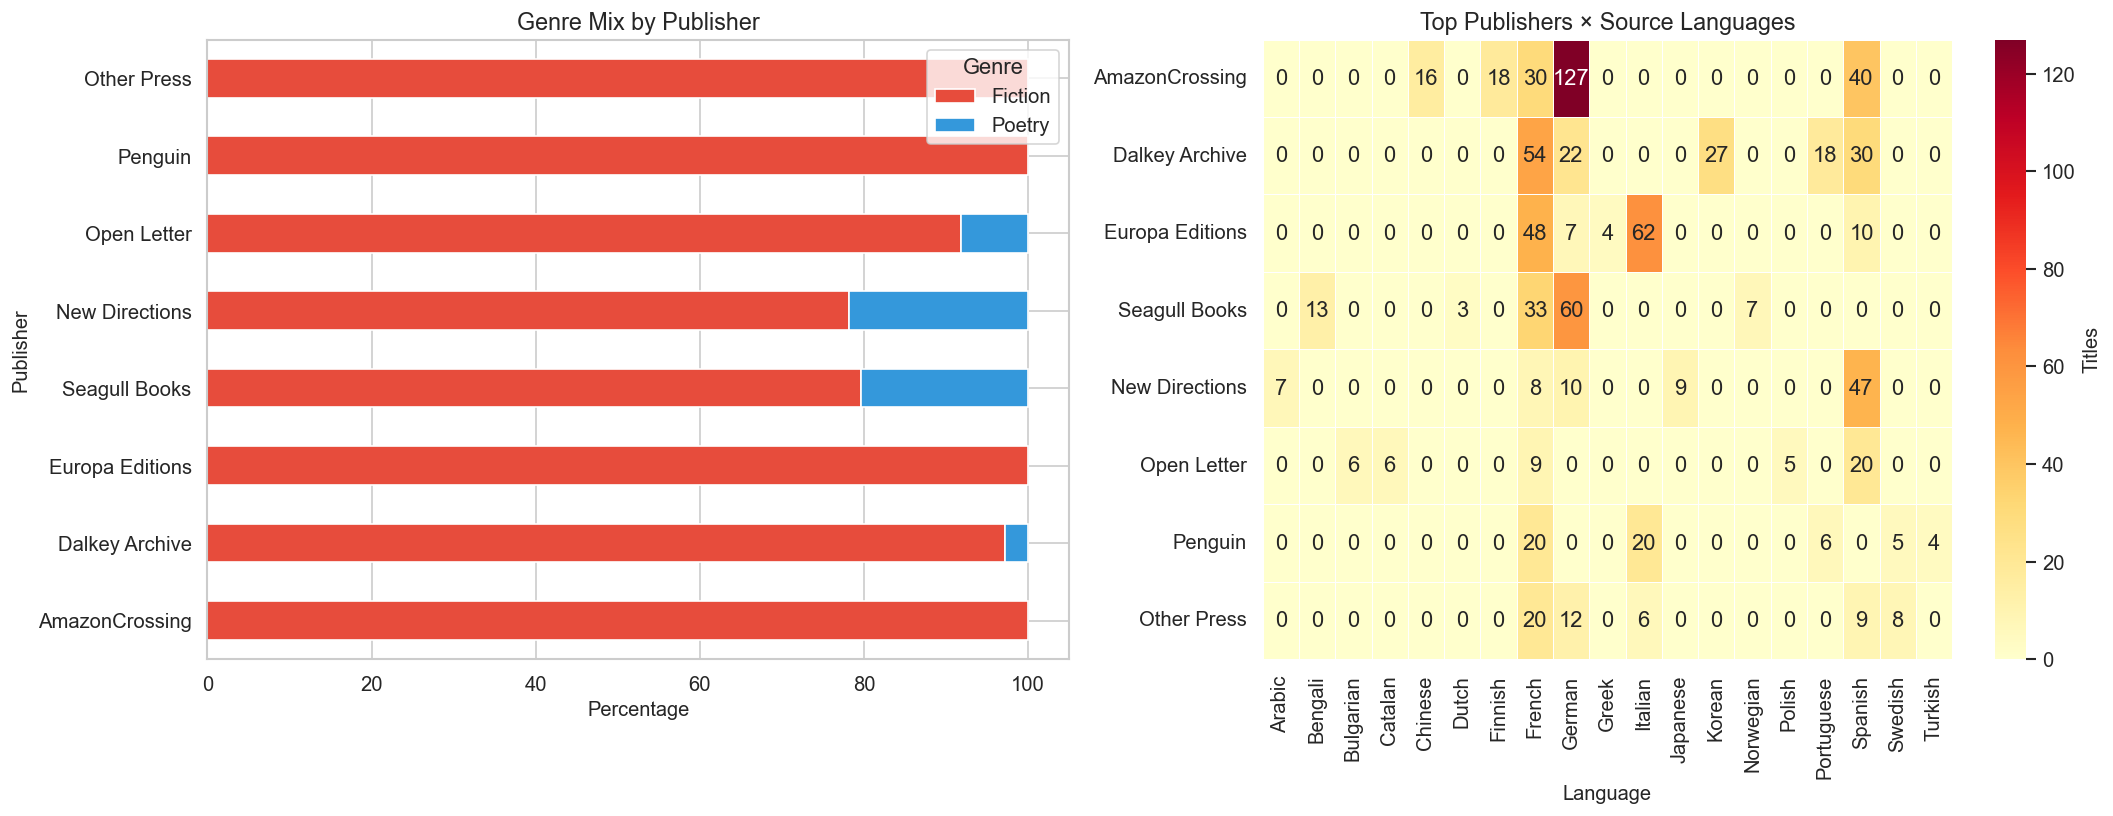

In [21]:
# ── 3c. Publisher specialization — genre and language mix ──
top8_pubs = df['Publisher'].value_counts().head(8).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Genre mix
genre_mix = df[df['Publisher'].isin(top8_pubs)].groupby(['Publisher', 'Genre']).size().unstack(fill_value=0)
genre_mix = genre_mix.loc[top8_pubs]
genre_pct = genre_mix.div(genre_mix.sum(axis=1), axis=0) * 100
genre_pct.plot(kind='barh', stacked=True, ax=axes[0],
    color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('Genre Mix by Publisher')
axes[0].set_xlabel('Percentage')
axes[0].legend(title='Genre')

# Top language for each publisher
lang_data = []
for pub in top8_pubs:
    pub_df = df[df['Publisher'] == pub]
    top3 = pub_df['Language'].value_counts().head(5)
    for lang, cnt in top3.items():
        lang_data.append({'Publisher': pub, 'Language': lang, 'Count': cnt})

lang_df = pd.DataFrame(lang_data)
pivot = lang_df.pivot_table(index='Publisher', columns='Language', values='Count', fill_value=0)
pivot = pivot.loc[top8_pubs]
# Keep only languages that appear
pivot = pivot.loc[:, pivot.sum() > 0]

sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', ax=axes[1],
    linewidths=0.5, cbar_kws={'label': 'Titles'})
axes[1].set_title('Top Publishers × Source Languages')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 4. Most-Translated Authors

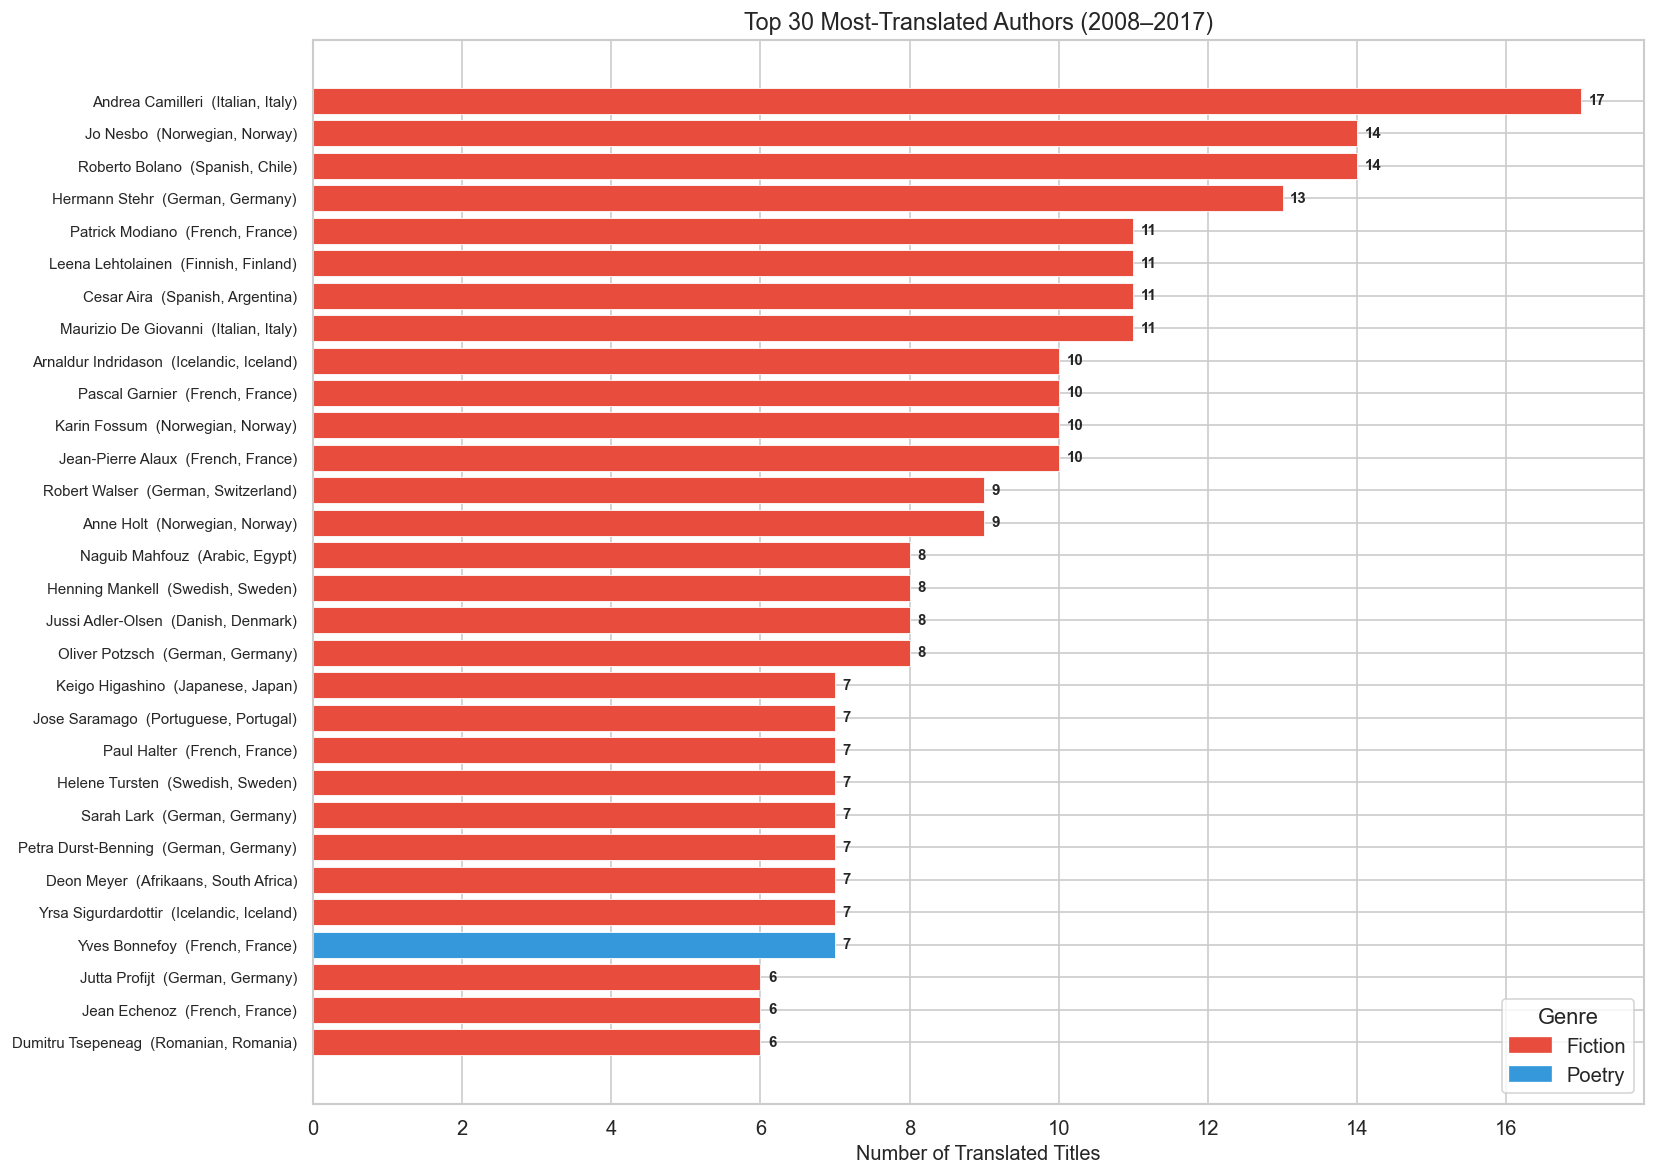

In [22]:
# ── 4a. Top 30 most-translated authors ──
author_counts = df.groupby('Author').agg(
    Titles=('Title', 'count'),
    Language=('Language', 'first'),
    Country=('Country', 'first'),
    Genre=('Genre', 'first'),
    Gender=('Author Gender', 'first')
).sort_values('Titles', ascending=False)

top30 = author_counts.head(30)

fig, ax = plt.subplots(figsize=(14, 10))
genre_colors = {'Fiction': '#e74c3c', 'Poetry': '#3498db'}
bar_colors = [genre_colors.get(g, 'gray') for g in top30['Genre']]

bars = ax.barh(range(len(top30)), top30['Titles'].values, color=bar_colors,
    edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top30)))
labels = [f"{name}  ({row['Language']}, {row['Country']})" 
          for name, row in top30.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Translated Titles')
ax.set_title('Top 30 Most-Translated Authors (2008–2017)')

for i, v in enumerate(top30['Titles'].values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9, fontweight='bold')

# Legend
patches = [mpatches.Patch(color=c, label=g) for g, c in genre_colors.items()]
ax.legend(handles=patches, title='Genre', loc='lower right')

plt.tight_layout()
plt.show()

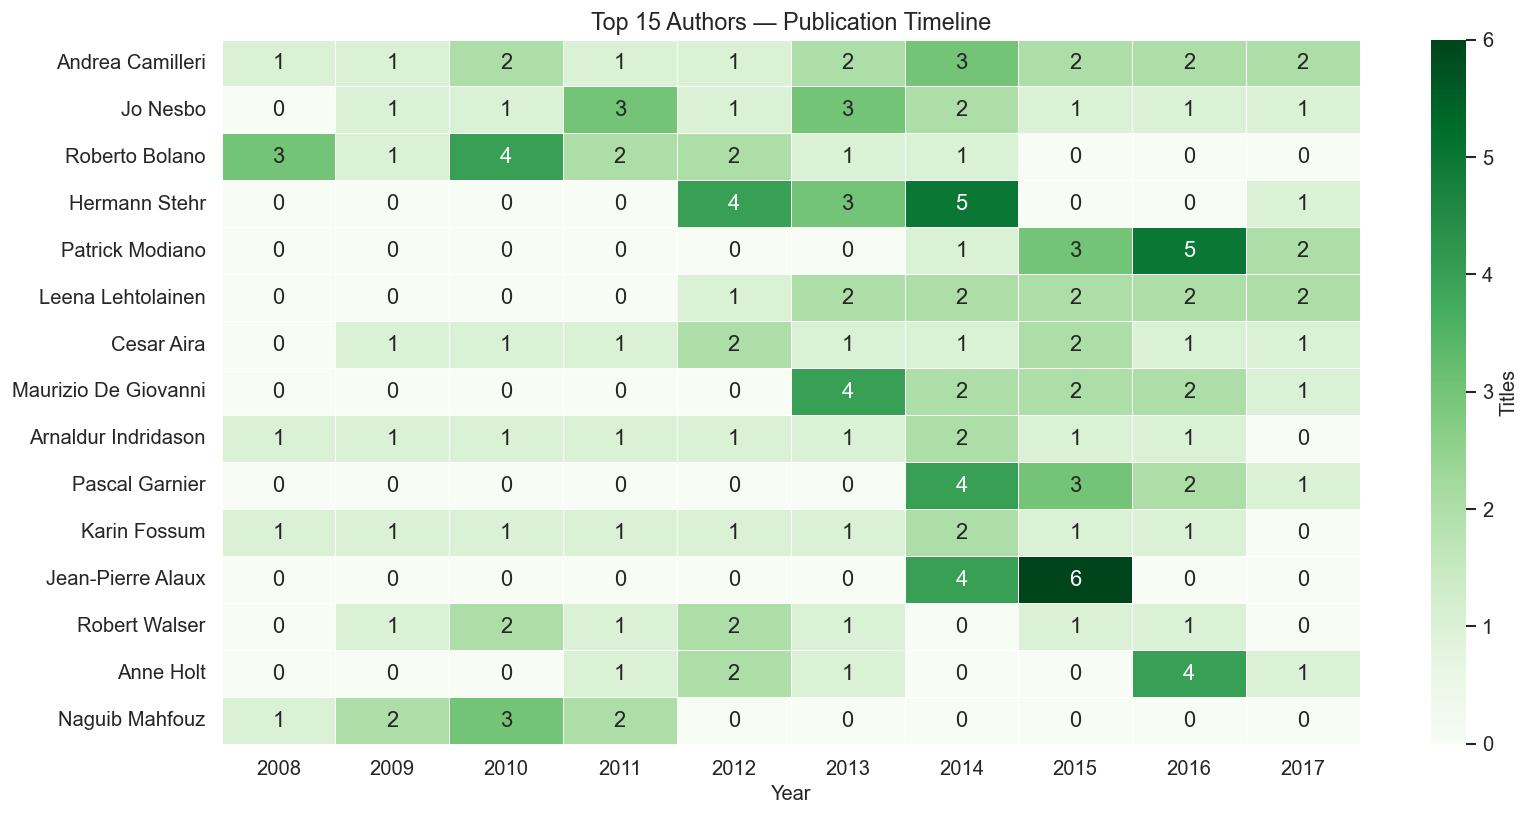

In [23]:
# ── 4b. Top authors — publishing timeline ──
top15_authors = author_counts.head(15).index.tolist()
auth_timeline = df[df['Author'].isin(top15_authors)].groupby(['Pub Year', 'Author']).size().unstack(fill_value=0)
auth_timeline = auth_timeline[top15_authors]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(auth_timeline.T, annot=True, fmt='d', cmap='Greens',
    linewidths=0.5, cbar_kws={'label': 'Titles'}, ax=ax)
ax.set_title('Top 15 Authors — Publication Timeline')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

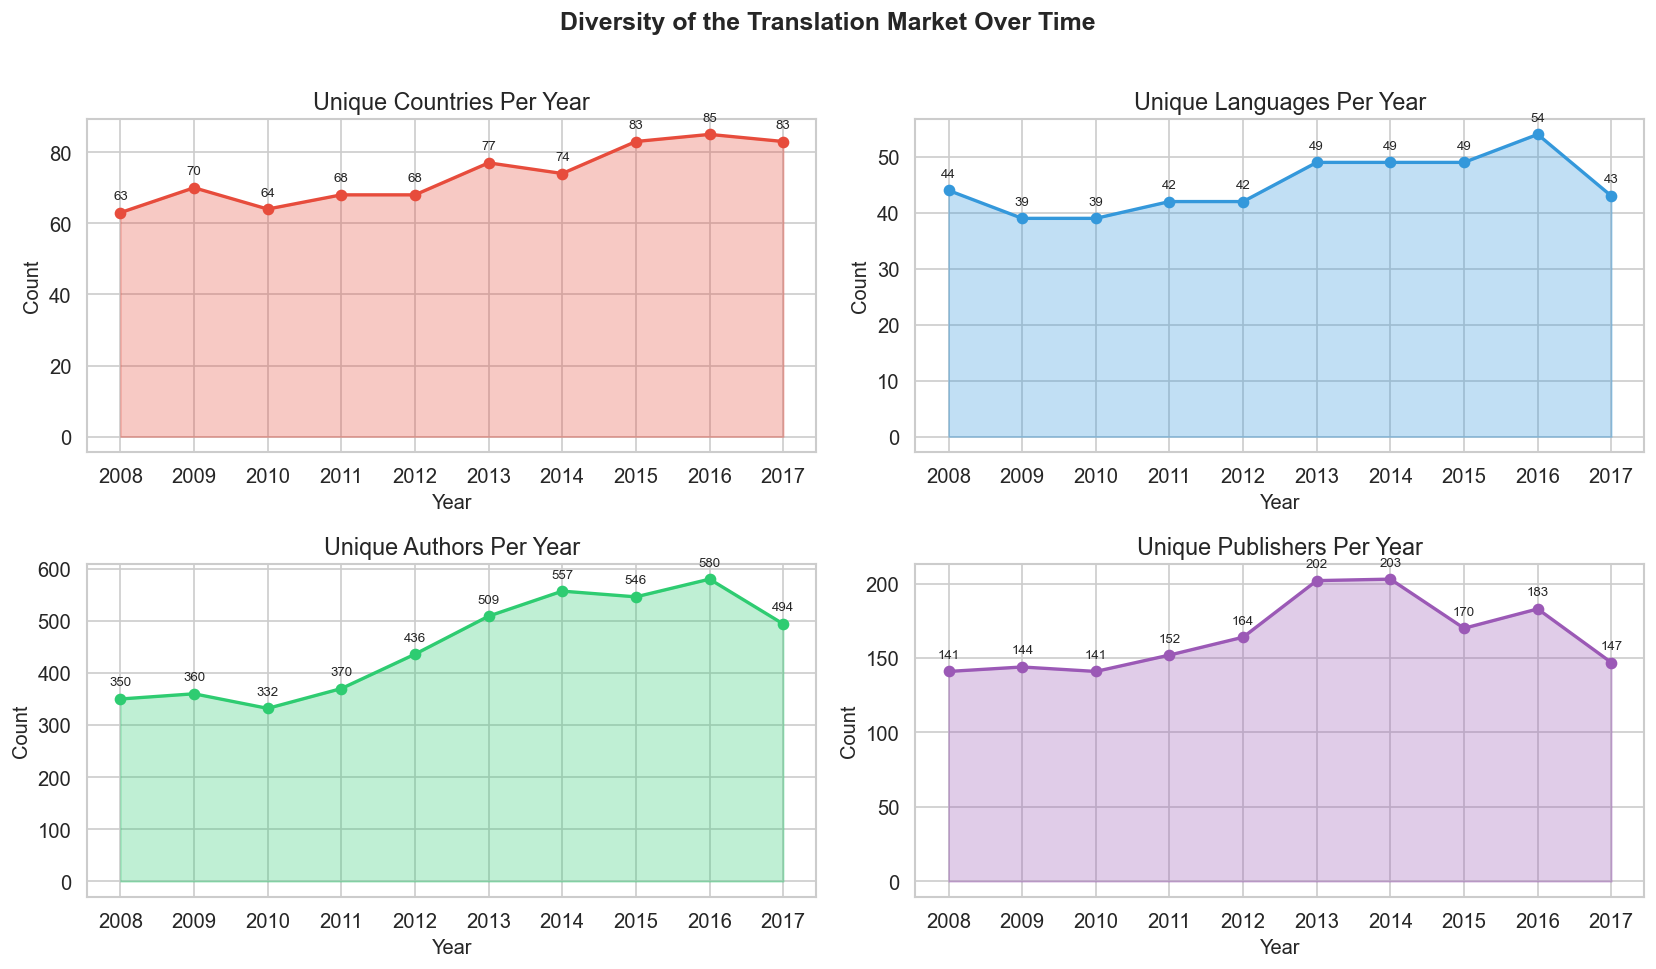

In [24]:
# ── 4c. Author nationality diversity — how many countries per year? ──
diversity = df.groupby('Pub Year').agg(
    Countries=('Country', 'nunique'),
    Languages=('Language', 'nunique'),
    Authors=('Author', 'nunique'),
    Publishers=('Publisher', 'nunique')
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metrics = ['Countries', 'Languages', 'Authors', 'Publishers']
colors_d = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors_d)):
    ax = axes[i // 2][i % 2]
    ax.fill_between(diversity.index, diversity[metric], alpha=0.3, color=color)
    ax.plot(diversity.index, diversity[metric], 'o-', color=color, lw=2)
    ax.set_title(f'Unique {metric} Per Year')
    ax.set_xlabel('Year')
    ax.set_ylabel(f'Count')
    ax.set_xticks(range(2008, 2018))
    for x, y in zip(diversity.index, diversity[metric]):
        ax.annotate(str(y), (x, y), textcoords='offset points',
            xytext=(0, 8), ha='center', fontsize=8)

fig.suptitle('Diversity of the Translation Market Over Time', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Gender Breakdown

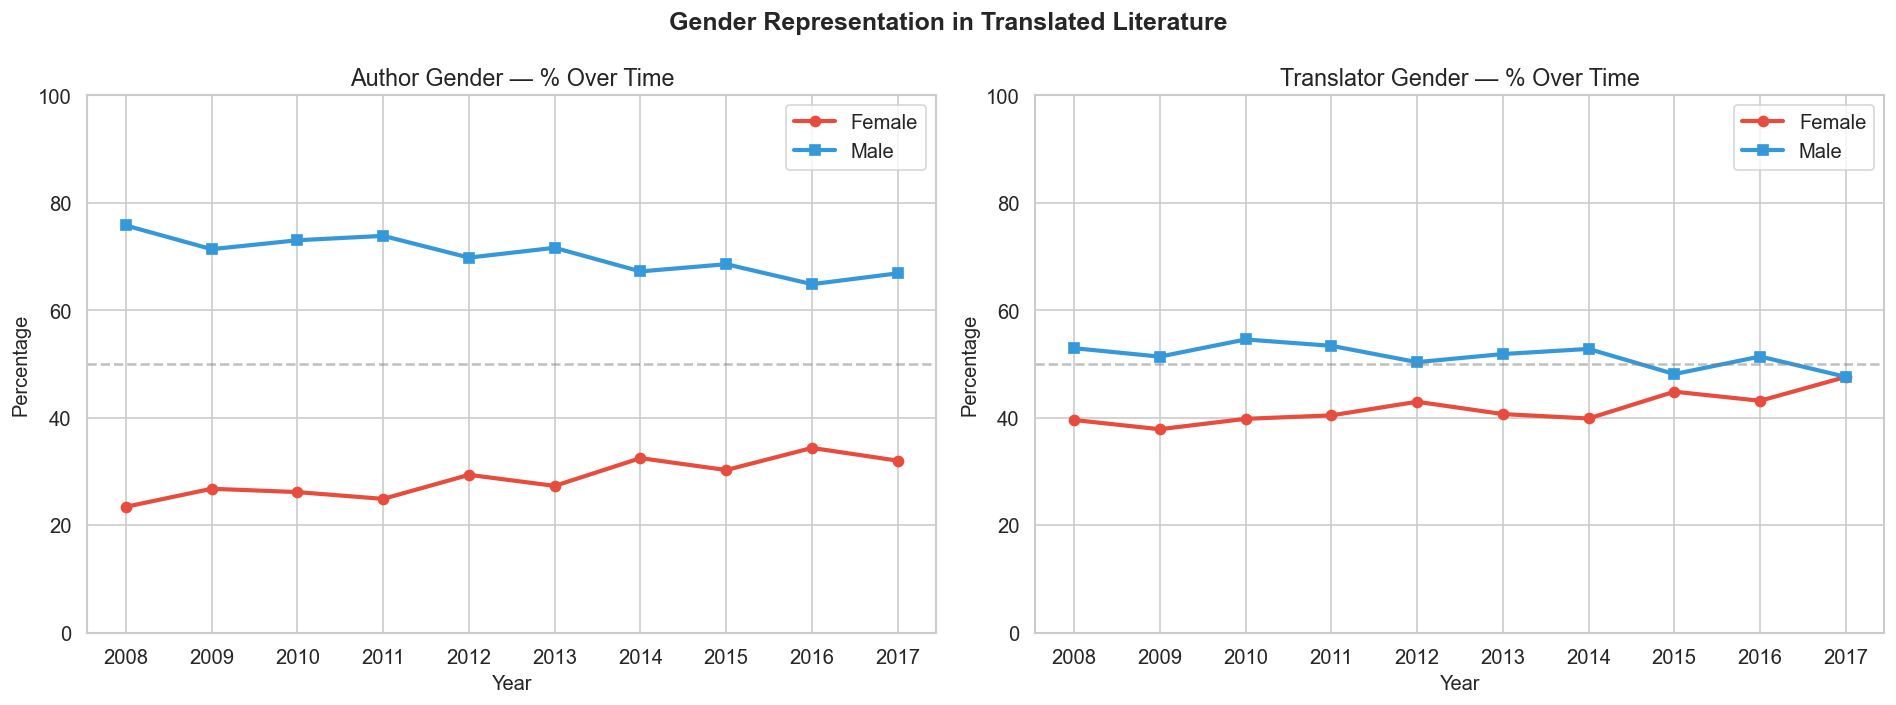

In [25]:
# ── 5a. Author & Translator gender over time ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (col, title) in enumerate([('Author Gender', 'Author Gender'),
                                      ('Translator Gender', 'Translator Gender')]):
    gender_year = df.groupby(['Pub Year', col]).size().unstack(fill_value=0)
    gender_pct = gender_year.div(gender_year.sum(axis=1), axis=0) * 100
    
    ax = axes[idx]
    if 'Female' in gender_pct.columns:
        ax.plot(gender_pct.index, gender_pct['Female'], 'o-',
            color='#e74c3c', lw=2.5, label='Female', markersize=6)
    if 'Male' in gender_pct.columns:
        ax.plot(gender_pct.index, gender_pct['Male'], 's-',
            color='#3498db', lw=2.5, label='Male', markersize=6)
    
    ax.set_title(f'{title} — % Over Time')
    ax.set_xlabel('Year')
    ax.set_ylabel('Percentage')
    ax.set_xticks(range(2008, 2018))
    ax.set_ylim(0, 100)
    ax.axhline(50, color='gray', ls='--', alpha=0.5)
    ax.legend()

plt.suptitle('Gender Representation in Translated Literature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

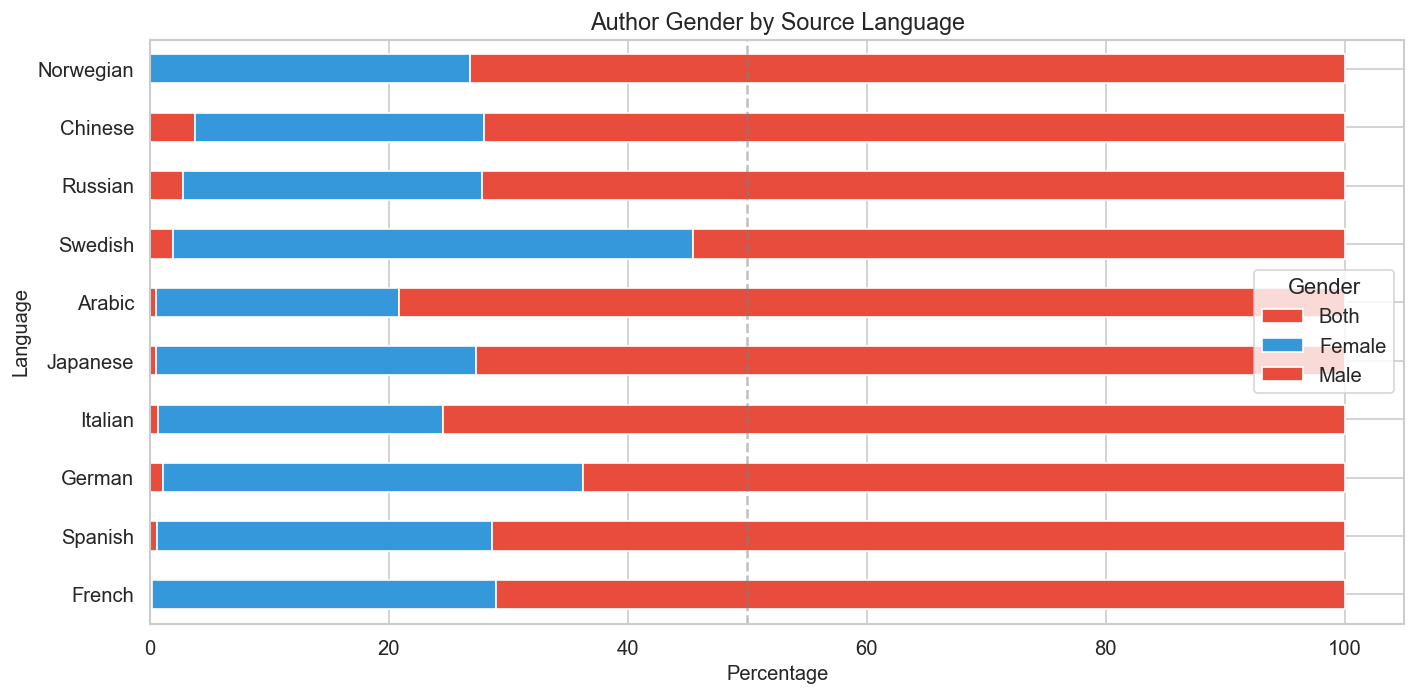

In [26]:
# ── 5b. Gender by source language ──
top8_langs = df['Language'].value_counts().head(10).index.tolist()
gender_lang = df[df['Language'].isin(top8_langs)].groupby(['Language', 'Author Gender']).size().unstack(fill_value=0)
gender_lang = gender_lang.loc[top8_langs]
gender_lang_pct = gender_lang.div(gender_lang.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
gender_lang_pct.plot(kind='barh', stacked=True, ax=ax,
    color=['#e74c3c', '#3498db'], edgecolor='white')
ax.set_title('Author Gender by Source Language')
ax.set_xlabel('Percentage')
ax.axvline(50, color='gray', ls='--', alpha=0.5)
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

---
## 6. Summary Statistics

In [27]:
# ── Final summary table ──
print('=' * 60)
print('TRANSLATION DATABASE SUMMARY — 2008 to 2017')
print('=' * 60)
print(f'Total translated titles:       {len(df):>6,}')
print(f'  Fiction:                      {(df["Genre"]=="Fiction").sum():>6,}')
print(f'  Poetry:                       {(df["Genre"]=="Poetry").sum():>6,}')
print(f'Unique source languages:        {df["Language"].nunique():>6}')
print(f'Unique source countries:        {df["Country"].nunique():>6}')
print(f'Unique publishers:              {df["Publisher"].nunique():>6}')
print(f'Unique authors:                 {df["Author"].nunique():>6}')
print(f'Unique translators:             {df["Translator"].nunique():>6}')
print(f'\nGrowth (2008 → 2017):           {total_year.iloc[0]} → {total_year.iloc[-1]} '
      f'({(total_year.iloc[-1]/total_year.iloc[0]-1)*100:+.0f}%)')
print(f'Average titles/year:            {len(df)/10:>6.0f}')
print(f'\nTop language:                   {df["Language"].value_counts().index[0]} '
      f'({df["Language"].value_counts().iloc[0]} titles)')
print(f'Top country:                    {df["Country"].value_counts().index[0]} '
      f'({df["Country"].value_counts().iloc[0]} titles)')
print(f'Top publisher:                  {df["Publisher"].value_counts().index[0]} '
      f'({df["Publisher"].value_counts().iloc[0]} titles)')
print(f'Most-translated author:         {author_counts[author_counts.index != "Various"].index[0]} '
      f'({author_counts.iloc[0]["Titles"]} titles)')
print(f'\nAuthor gender (overall):        '
      f'{(df["Author Gender"]=="Female").sum()/(df["Author Gender"].notna()).sum()*100:.1f}% female / '
      f'{(df["Author Gender"]=="Male").sum()/(df["Author Gender"].notna()).sum()*100:.1f}% male')
print(f'Translator gender (overall):    '
      f'{(df["Translator Gender"]=="Female").sum()/(df["Translator Gender"].notna()).sum()*100:.1f}% female / '
      f'{(df["Translator Gender"]=="Male").sum()/(df["Translator Gender"].notna()).sum()*100:.1f}% male')
print('=' * 60)

TRANSLATION DATABASE SUMMARY — 2008 to 2017
Total translated titles:        4,808
  Fiction:                       3,941
  Poetry:                          867
Unique source languages:            78
Unique source countries:           134
Unique publishers:                 517
Unique authors:                   3250
Unique translators:               2167

Growth (2008 → 2017):           359 → 521 (+45%)
Average titles/year:               481

Top language:                   French (821 titles)
Top country:                    France (564 titles)
Top publisher:                  AmazonCrossing (316 titles)
Most-translated author:         Andrea Camilleri (17 titles)

Author gender (overall):        29.3% female / 69.7% male
Translator gender (overall):    42.0% female / 51.2% male
